<a href="https://colab.research.google.com/github/MARISETTIGAYATRI/-Prediction-of-Agriculture-Crop-Production/blob/main/final%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder ,OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, r2_score
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer

## Reading Dataset

In [7]:
df= pd.read_csv('/content/Customer_support_data (1).csv')
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [9]:
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [10]:
df.dtypes

,0
Unique id,object
channel_name,object
category,object
Sub-category,object
Customer Remarks,object
Order_id,object
order_date_time,object
Issue_reported at,object
issue_responded,object
Survey_response_Date,object


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


In [13]:
df['Item_price'].value_counts()

,count
Item_price,
999.0,590
1499.0,326
899.0,309
1299.0,301
799.0,283
...,...
4974.0,1
4065.0,1
3674.0,1


In [14]:
df['Item_price'].median()

979.0

## Data Preprocessing

In [15]:
# Drop unnecessary columns
df_cleaned = df.drop(['Unique id',"Customer Remarks", "Order_id", "order_date_time",
                     "Customer_City", "Product_category", "connected_handling_time"], axis=1)

# Imputing missing values for numerical features
df_cleaned["Item_price"].fillna(df_cleaned["Item_price"].median(), inplace=True)


# Converting timestamp columns to datetime format
timestamp_columns = ["Issue_reported at", "issue_responded", "Survey_response_Date"]
for column in timestamp_columns:
    df_cleaned[column] = pd.to_datetime(df_cleaned[column], errors='coerce')

# Imputing missing values for timestamp features
for column in ["Issue_reported at", "issue_responded"]:
    df_cleaned[column].fillna(df_cleaned[column].median(), inplace=True)

In [16]:
df_cleaned.isna().sum()

,0
channel_name,0
category,0
Sub-category,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0
Item_price,0
Agent_name,0
Supervisor,0
Manager,0


In [17]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   channel_name          85907 non-null  object        
 1   category              85907 non-null  object        
 2   Sub-category          85907 non-null  object        
 3   Issue_reported at     85907 non-null  datetime64[ns]
 4   issue_responded       85907 non-null  datetime64[ns]
 5   Survey_response_Date  85907 non-null  datetime64[ns]
 6   Item_price            85907 non-null  float64       
 7   Agent_name            85907 non-null  object        
 8   Supervisor            85907 non-null  object        
 9   Manager               85907 non-null  object        
 10  Tenure Bucket         85907 non-null  object        
 11  Agent Shift           85907 non-null  object        
 12  CSAT Score            85907 non-null  int64         
dtypes: datetime64[ns

## Exploratory Data Analysis

In [18]:
template = "simple_white"

csat_distribution_by_shift_fig = px.box(df_cleaned, x='Agent Shift', y='CSAT Score', color='Agent Shift',
                                         title='Distribution of CSAT Scores by Agent Shift',
                                         labels={'Agent Shift': 'Agent Shift', 'CSAT Score': 'CSAT Score'},
                                         template=template)
csat_distribution_by_shift_fig.update_layout(
    xaxis=dict(title="Agent Shift"),
    yaxis=dict(title='CSAT Score'),
    font=dict(family='Arial', size=12, color='black')
)

csat_distribution_by_shift_fig.show()

In [19]:
# Distribution of CSAT scores
csat_distribution_fig = px.histogram(df_cleaned, x='CSAT Score', title='Distribution of CSAT Scores',
                                     labels={'CSAT Score': 'CSAT Score'},
                                     color='CSAT Score', template=template)
csat_distribution_fig.update_layout(
    xaxis=dict(title='CSAT Score', tickmode='linear'),
    yaxis=dict(title='Count'),
    font=dict(family='Arial', size=15, color='black')
)

csat_distribution_fig.show()

In [20]:
df_cleaned['Item_price'].value_counts()

,count
Item_price,
979.0,68708
999.0,590
1499.0,326
899.0,309
1299.0,301
...,...
1078.0,1
5424.0,1
888.0,1


In [21]:
df_cleaned.shape

(85907, 13)

In [22]:
# Pie chart
pie_chart_fig = px.pie(df_cleaned, names='channel_name', title='Channel Distribution',
                       labels={'channel_name': 'Channel'},
                       template=template)
pie_chart_fig.update_layout(font=dict(family='Arial', size=12, color='black'))

pie_chart_fig.show()

In [23]:
# Sunburst chart of category and sub-category distribution
sunburst_chart_fig = px.sunburst(df_cleaned, path=['category', 'Sub-category'], title='Category and Sub-category Distribution',
                                 labels={'category': 'Category', 'Sub-category': 'Sub-category'},
                                 template=template)
sunburst_chart_fig.update_layout(font=dict(family='Arial', size=12, color='black'))

sunburst_chart_fig.show()

In [24]:
# Extracting month information from the Survey_response_Date
df_cleaned['Month'] = df_cleaned['Survey_response_Date'].dt.to_period('M')

# Monthly CSAT distribution
monthly_csat_dist_fig = px.histogram(df_cleaned, x='CSAT Score', color='CSAT Score', facet_col='Month',
                                      title='Monthly CSAT Distribution',
                                      labels={'CSAT Score': 'CSAT Score', 'Month': 'Month'},
                                      template=template)
monthly_csat_dist_fig.update_layout(font=dict(family='Arial', size=12, color='black'))

monthly_csat_dist_fig.show()

In [25]:
# Top agents by CSAT score bar chart
top_agents_csat_bar_fig = px.bar(df_cleaned.groupby('Agent_name')['CSAT Score'].mean().reset_index().nlargest(10, 'CSAT Score'),
                                  x='Agent_name', y='CSAT Score', title='Top Agents by CSAT Score',
                                  labels={'Agent_name': 'Agent Name', 'CSAT Score': 'Average CSAT Score'},
                                  color='CSAT Score', template=template)
top_agents_csat_bar_fig.update_layout(font=dict(family='Arial', size=12, color='black'))

top_agents_csat_bar_fig.show()

In [26]:
# Agent tenure bucket distribution
tenure_bucket_dist_fig = px.histogram(df_cleaned, x='Tenure Bucket', title='Agent Tenure Bucket Distribution',
                                       labels={'Tenure Bucket': 'Tenure Bucket'},
                                       color='Tenure Bucket', template=template)
tenure_bucket_dist_fig.update_layout(font=dict(family='Arial', size=12, color='black'))

tenure_bucket_dist_fig.show()

In [27]:
# CSAT scores by channel
csat_by_channel_fig = px.box(df_cleaned, x='channel_name', y='CSAT Score',
                             title='CSAT Scores by Channel',
                             labels={'channel_name': 'Channel', 'CSAT Score': 'CSAT Score'},
                             color='channel_name', template=template)
csat_by_channel_fig.update_layout(
    xaxis=dict(title='Channel'),
    yaxis=dict(title='CSAT Score'),
    font=dict(family='Arial', size=12, color='black')
)

csat_by_channel_fig.show()

In [28]:
df_cleaned.columns

Index(['channel_name', 'category', 'Sub-category', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'Month'],
      dtype='object')

In [29]:
print(df.shape, df_cleaned.shape)

(85907, 20) (85907, 14)


In [30]:
df_cleaned.head()

,channel_name,category,Sub-category,Issue_reported at,issue_responded,Survey_response_Date,Item_price,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Month
0,Outcall,Product Queries,Life Insurance,2023-01-08 11:13:00,2023-01-08 11:47:00,2023-08-01,979.0,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,2023-08
1,Outcall,Product Queries,Product Specific Information,2023-01-08 12:52:00,2023-01-08 12:54:00,2023-08-01,979.0,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2023-08
2,Inbound,Order Related,Installation/demo,2023-01-08 20:16:00,2023-01-08 20:38:00,2023-08-01,979.0,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,2023-08
3,Inbound,Returns,Reverse Pickup Enquiry,2023-01-08 20:56:00,2023-01-08 21:16:00,2023-08-01,979.0,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,2023-08
4,Inbound,Cancellation,Not Needed,2023-01-08 10:30:00,2023-01-08 10:32:00,2023-08-01,979.0,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2023-08


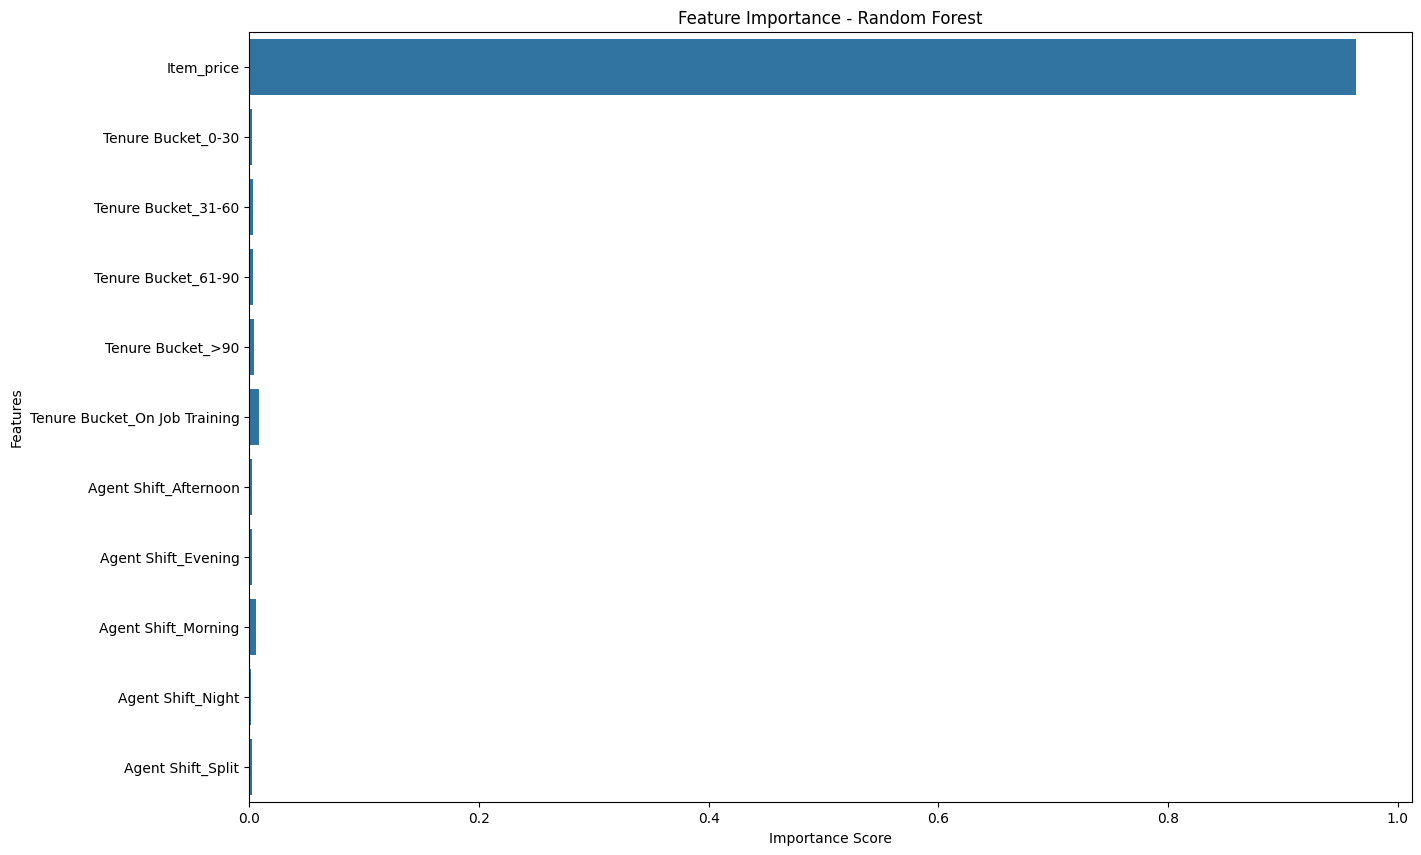

In [31]:
# Selecting relevant features and target variable
features = df_cleaned[['Item_price', 'Tenure Bucket', 'Agent Shift']]
target = df_cleaned['CSAT Score']

# Converting categorical features to numerical using one-hot encoding
features_encoded = pd.get_dummies(features)

# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_encoded, target, test_size=0.2, random_state=42)

# Creating a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fitting the model to the training data
rf_model.fit(X_train, y_train)

# Plot feature importance
plt.figure(figsize=(15, 10))
sns.barplot(x=rf_model.feature_importances_, y=features_encoded.columns)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [32]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression,Ridge ,Lasso
from sklearn.preprocessing import StandardScaler ,PolynomialFeatures , OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

## Model Training and Evaluation

In [33]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

def tune_and_evaluate_classification(model, param_grid):
    cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=42)

    # Hyperparameter tuning with RepeatedStratifiedKFold
    grid_search = GridSearchCV(model, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=True)
    grid_search.fit(X_train, y_train)
    model = grid_search.best_estimator_

    print("Best Parameters: ", grid_search.best_params_)
    print("Mean of cross-validation scores: ", grid_search.best_score_)

    # Measuring accuracy
    print("Training set Accuracy:", round(model.score(X_train, y_train), 4) * 100)
    print("Testing set Accuracy:", round(model.score(X_test, y_test), 4) * 100)

    # Predictions
    y_pred = model.predict(X_test)

    # Calculating Precision, Recall, F1-Score
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Classification Report and Confusion Matrix
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    return model


In [34]:
df_cleaned.columns

Index(['channel_name', 'category', 'Sub-category', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'Month'],
      dtype='object')

### Splitting Dataset

In [35]:
features = df_cleaned.columns.drop(['Issue_reported at', 'issue_responded', 'Survey_response_Date',
                                    'CSAT Score', 'Month'])
target = 'CSAT Score'

X = df_cleaned[features]
y = df_cleaned[target]

num_features = X.select_dtypes('number').columns
cat_features = X.select_dtypes(['object','category']).columns

X_train , X_test , y_train ,y_test = train_test_split(X,y,test_size=0.15,random_state=42)

In [36]:
num_features, cat_features

(Index(['Item_price'], dtype='object'),
 Index(['channel_name', 'category', 'Sub-category', 'Agent_name', 'Supervisor',
        'Manager', 'Tenure Bucket', 'Agent Shift'],
       dtype='object'))

### Pipeline Creation

In [37]:
# Numerical pipeline
num_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),  # Use mean imputation for numerical features
    StandardScaler(),  # Scaling numerical features
    PolynomialFeatures(degree=2)
)

# Categorical pipeline
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),  # Impute missing values with the most frequent category
    OneHotEncoder(handle_unknown="ignore")  # Encode categorical variables with one-hot encoding
)

# Full pipeline combining both numerical and categorical transformations
preprocessor = make_column_transformer(
    (num_pipeline, num_features),  # num_features: list of numerical feature names
    (cat_pipeline, cat_features)   # cat_features: list of categorical feature names
)

In [38]:
preprocessor

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler()),
                                                 ('polynomialfeatures',
                                                  PolynomialFeatures())]),
                                 Index(['Item_price'], dtype='object')),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['channel_name', 'category', 'Sub-category', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift'],
      dtype='object'))])

### Logistic Regression

Fitting 6 folds for each of 1 candidates, totalling 6 fits
Best Parameters:  {'columntransformer__pipeline-1__polynomialfeatures__degree': 4}
Mean of cross-validation scores:  0.6932895097233635
Training set Accuracy: 69.35
Testing set Accuracy: 69.54
Precision: 0.5029
Recall: 0.6954
F1 Score: 0.5710

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      1678
           2       0.00      0.00      0.00       173
           3       0.00      0.00      0.00       381
           4       0.14      0.00      0.00      1689
           5       0.70      1.00      0.82      8966

    accuracy                           0.70     12887
   macro avg       0.17      0.20      0.16     12887
weighted avg       0.50      0.70      0.57     12887


Confusion Matrix:
[[   0    0    0    2 1676]
 [   0    0    0    0  173]
 [   0    1    0    1  379]
 [   0    1    0    1 1687]
 [   2    0    0    3 8961]]


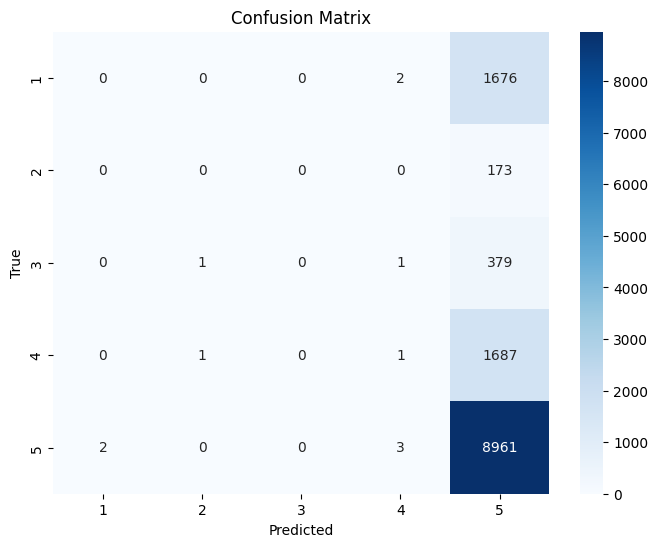

In [39]:
from sklearn.linear_model import LogisticRegression
# Logistic Regression Model Building
lin_reg = make_pipeline(
    preprocessor,
    LogisticRegression()
)
#hyperparameter tunning
param_grid = {'columntransformer__pipeline-1__polynomialfeatures__degree':[4]}
lin_reg = tune_and_evaluate_classification(lin_reg, param_grid)

### Random Forest

Fitting 6 folds for each of 1 candidates, totalling 6 fits
Best Parameters:  {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 10}
Mean of cross-validation scores:  0.6936729663105998
Training set Accuracy: 69.37
Testing set Accuracy: 69.57
Precision: 0.4840
Recall: 0.6957
F1 Score: 0.5709

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      1678
           2       0.00      0.00      0.00       173
           3       0.00      0.00      0.00       381
           4       0.00      0.00      0.00      1689
           5       0.70      1.00      0.82      8966

    accuracy                           0.70     12887
   macro avg       0.14      0.20      0.16     12887
weighted avg       0.48      0.70      0.57     12887


Confusion Matrix:
[[

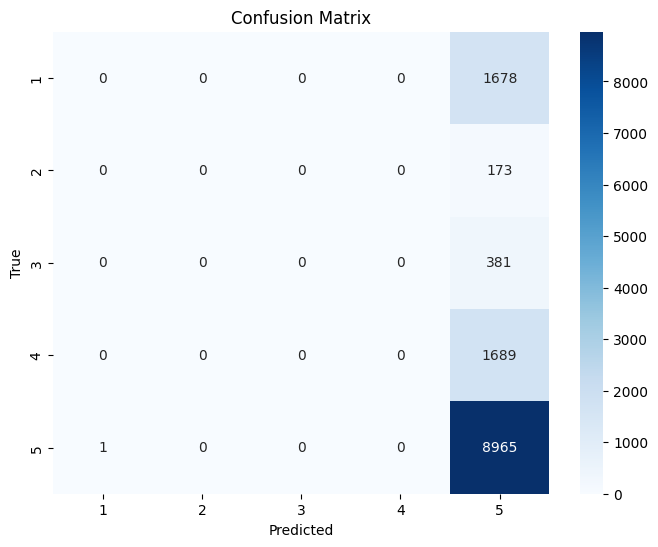

In [40]:
# RandomForest Classification Model
rf_clf = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42, n_jobs=-1, verbose=0)
)

param_grid = {
    'randomforestclassifier__n_estimators': [10],
    'randomforestclassifier__max_depth': [10],
    'randomforestclassifier__min_samples_split': [2],
    'randomforestclassifier__min_samples_leaf': [1],
    'randomforestclassifier__max_features': ['sqrt']
}

rf_clf = tune_and_evaluate_classification(rf_clf, param_grid)

In [41]:
print(rf_clf.named_steps['randomforestclassifier'])

RandomForestClassifier(max_depth=10, n_estimators=10, n_jobs=-1,
                       random_state=42)


In [42]:
y_train = y_train - 1
y_test = y_test - 1

### XGBoost

Fitting 6 folds for each of 1 candidates, totalling 6 fits
Best Parameters:  {'columntransformer__pipeline-1__polynomialfeatures__degree': 4, 'xgbclassifier__colsample_bytree': 0.5, 'xgbclassifier__gamma': 0.2, 'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 9, 'xgbclassifier__min_child_weight': 5, 'xgbclassifier__n_estimators': 1500}
Mean of cross-validation scores:  0.6948096411941934
Training set Accuracy: 70.17999999999999
Testing set Accuracy: 69.71000000000001
Precision: 0.5490
Recall: 0.6971
F1 Score: 0.5856

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.06      0.11      1678
           1       0.00      0.00      0.00       173
           2       0.00      0.00      0.00       381
           3       0.00      0.00      0.00      1689
           4       0.70      0.99      0.82      8966

    accuracy                           0.70     12887
   macro avg       0.23      0.21      0.19     12887
wei

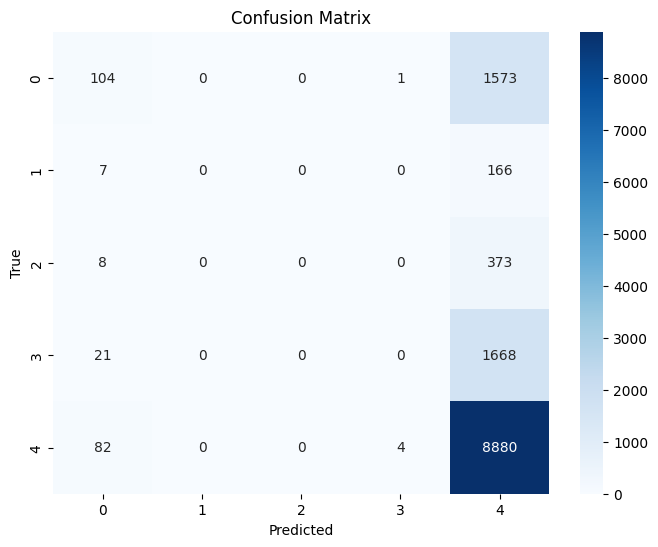

In [43]:
#xgb model building
from xgboost import XGBClassifier
xgb_reg = make_pipeline(
    preprocessor,
    XGBClassifier(device = "cuda", tree_method = "hist", n_jobs = -1, verbosity = 0)
)

param_grid={'columntransformer__pipeline-1__polynomialfeatures__degree':[4],
            'xgbclassifier__n_estimators': [1500],
    "xgbclassifier__learning_rate": ([0.05]),
                        "xgbclassifier__max_depth": [9],
                        "xgbclassifier__min_child_weight": [ 5],
                        "xgbclassifier__gamma":[ 0.2],
                        "xgbclassifier__colsample_bytree":[ 0.5]
}
xgb_reg = tune_and_evaluate_classification(xgb_reg, param_grid)

### Gradient Boosting

Fitting 6 folds for each of 1 candidates, totalling 6 fits
Best Parameters:  {'gradientboostingclassifier__n_estimators': 50}
Mean of cross-validation scores:  0.6935771021637908
Training set Accuracy: 69.61
Testing set Accuracy: 69.51
Precision: 0.5608
Recall: 0.6951
F1 Score: 0.5739

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.01      0.02      1678
           1       0.00      0.00      0.00       173
           2       0.00      0.00      0.00       381
           3       0.00      0.00      0.00      1689
           4       0.70      1.00      0.82      8966

    accuracy                           0.70     12887
   macro avg       0.26      0.20      0.17     12887
weighted avg       0.56      0.70      0.57     12887


Confusion Matrix:
[[  21    5    0    0 1652]
 [   1    0    0    0  172]
 [   0    1    0    0  380]
 [   3    3    0    0 1683]
 [  11   17    1    0 8937]]


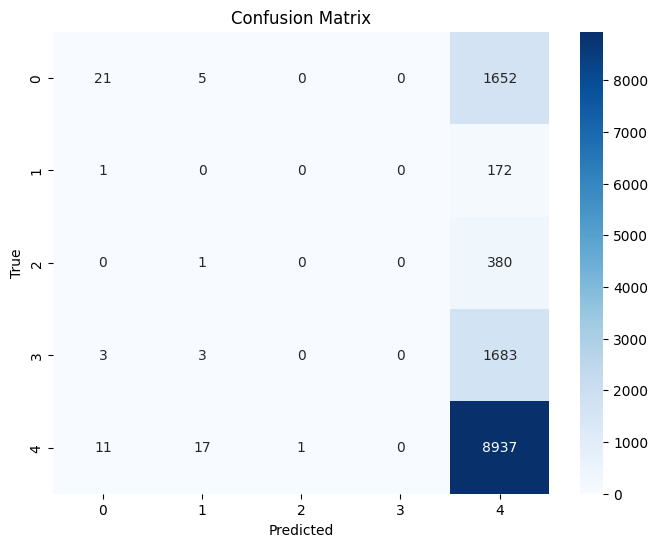

In [44]:
# GradientBoosting Classification Model
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = make_pipeline(
    preprocessor,
    GradientBoostingClassifier(random_state=42, verbose = 0)
)

param_grid = {
    'gradientboostingclassifier__n_estimators': [50]
}

gb_clf = tune_and_evaluate_classification(gb_clf, param_grid)

### Stacking Classifier

Fitting 6 folds for each of 1 candidates, totalling 6 fits
Best Parameters:  {'stackingclassifier__rf__max_depth': 5, 'stackingclassifier__rf__n_estimators': 50}
Mean of cross-validation scores:  0.6941248972884142
Training set Accuracy: 69.51
Testing set Accuracy: 69.64
Precision: 0.5551
Recall: 0.6964
F1 Score: 0.5753

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.02      0.03      1678
           1       0.00      0.00      0.00       173
           2       0.00      0.00      0.00       381
           3       0.00      0.00      0.00      1689
           4       0.70      1.00      0.82      8966

    accuracy                           0.70     12887
   macro avg       0.25      0.20      0.17     12887
weighted avg       0.56      0.70      0.58     12887


Confusion Matrix:
[[  28    0    0    0 1650]
 [   0    0    0    0  173]
 [   0    0    0    0  381]
 [   5    0    0    0 1684]
 [  19    0    0    0 8947]]


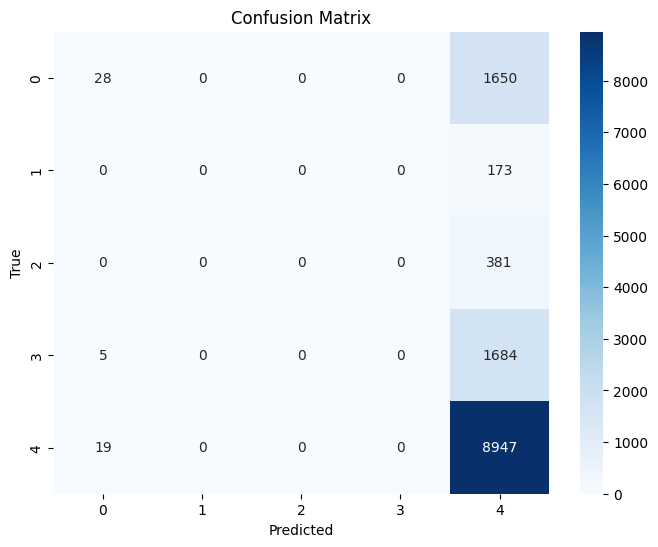

In [45]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import LinearSVC

estimators = [
    ('rf', RandomForestClassifier(n_estimators=10, random_state=42, n_jobs = -1)),
]

stack_cf = make_pipeline(
    preprocessor,
    StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(),n_jobs = -1, verbose = 1)
)

param_grid = {
    'stackingclassifier__rf__n_estimators': [50],  # RandomForest hyperparameters for base model
    'stackingclassifier__rf__max_depth': [5],  # Max depth for base RandomForest model
}

stack_cf = tune_and_evaluate_classification(stack_cf, param_grid)

### AdaBoost

Fitting 6 folds for each of 1 candidates, totalling 6 fits
Best Parameters:  {'adaboostclassifier__algorithm': 'SAMME', 'adaboostclassifier__learning_rate': 0.01, 'adaboostclassifier__n_estimators': 50}
Mean of cross-validation scores:  0.6936592714324843
Training set Accuracy: 69.37
Testing set Accuracy: 69.57
Precision: 0.4841
Recall: 0.6957
F1 Score: 0.5709

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1678
           1       0.00      0.00      0.00       173
           2       0.00      0.00      0.00       381
           3       0.00      0.00      0.00      1689
           4       0.70      1.00      0.82      8966

    accuracy                           0.70     12887
   macro avg       0.14      0.20      0.16     12887
weighted avg       0.48      0.70      0.57     12887


Confusion Matrix:
[[   0    0    0    0 1678]
 [   0    0    0    0  173]
 [   0    0    0    0  381]
 [   0    0    0    0

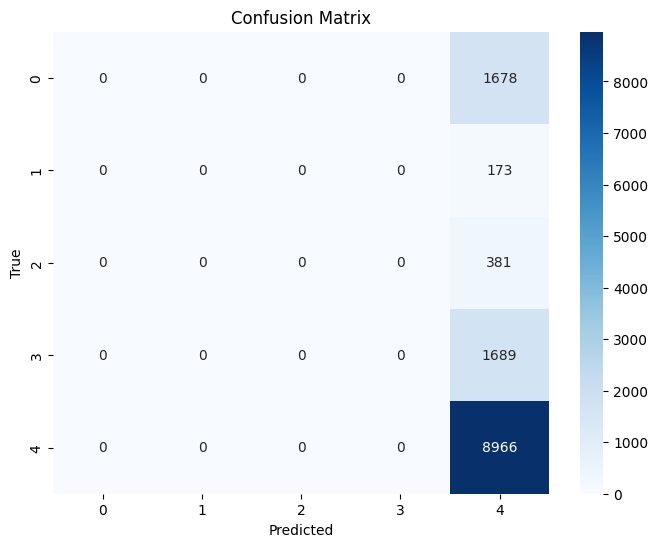

In [46]:
from sklearn.ensemble import AdaBoostClassifier

# AdaBoost Classification Model
adaboost_clf = make_pipeline(
    preprocessor,
    AdaBoostClassifier(random_state=42)
)

param_grid = {
    'adaboostclassifier__n_estimators': [50],  # Number of boosting stages
    'adaboostclassifier__learning_rate': [0.01],  # Learning rate
    'adaboostclassifier__algorithm': ['SAMME']  # Choose between SAMME and SAMME.R
}

adaboost_clf = tune_and_evaluate_classification(adaboost_clf, param_grid)